C:\Users\abhis\AppData\Local\Temp\ipykernel_36468\590422643.py:14: DtypeWarning: Columns (0,1,2,3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


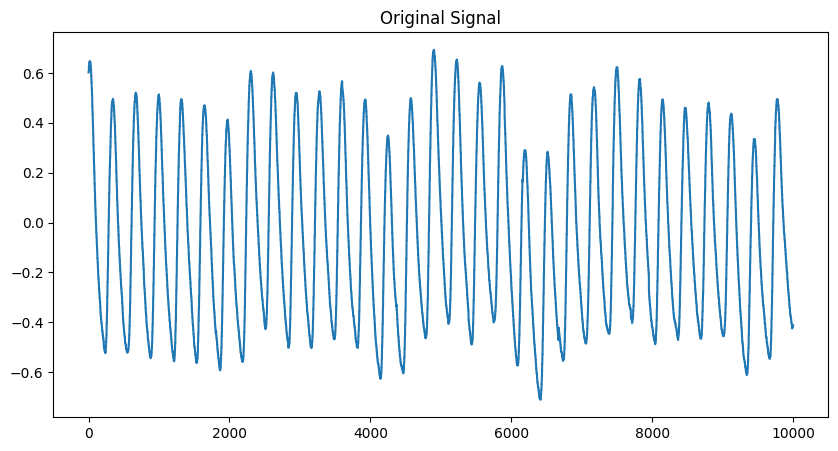

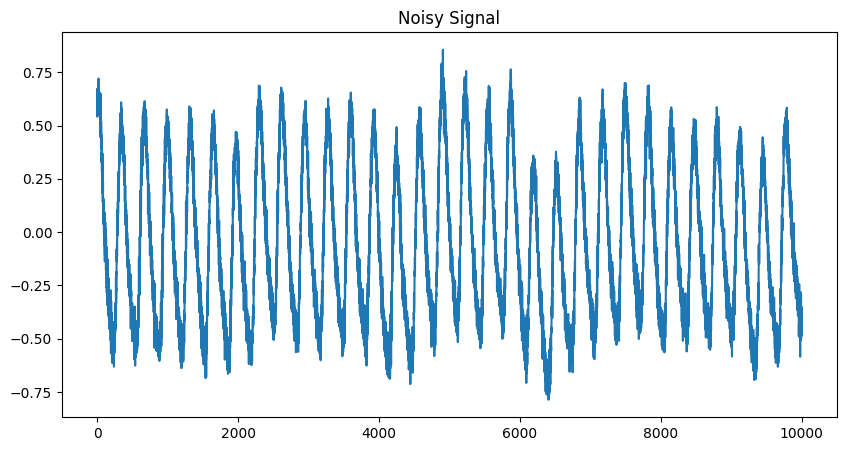

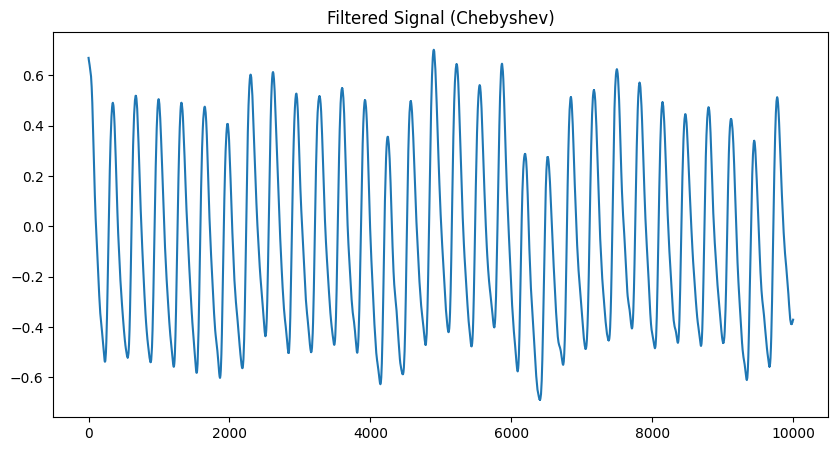

c:\Users\abhis\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0677 - mae: 0.2024 - val_loss: 0.0024 - val_mae: 0.0388
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0033 - mae: 0.0453 - val_loss: 0.0025 - val_mae: 0.0394
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0034 - mae: 0.0461 - val_loss: 0.0023 - val_mae: 0.0385
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0032 - mae: 0.0446 - val_loss: 0.0024 - val_mae: 0.0386
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0032 - mae: 0.0452 - val_loss: 0.0024 - val_mae: 0.0386
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0033 - mae: 0.0454 - val_loss: 0.0023 - val_mae: 0.0384
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0032 - mae: 0.0450 - val_loss: 0.0023 - val_mae: 0.0384
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0033 - mae: 0.0454 - val_loss: 0.0024 - val_mae: 0.0390
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - l

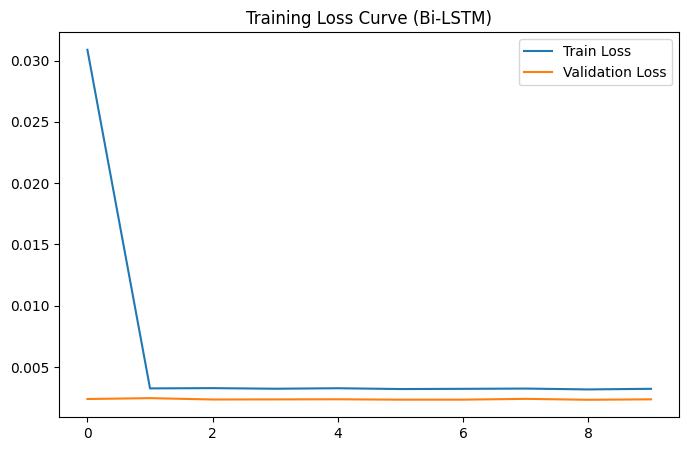

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


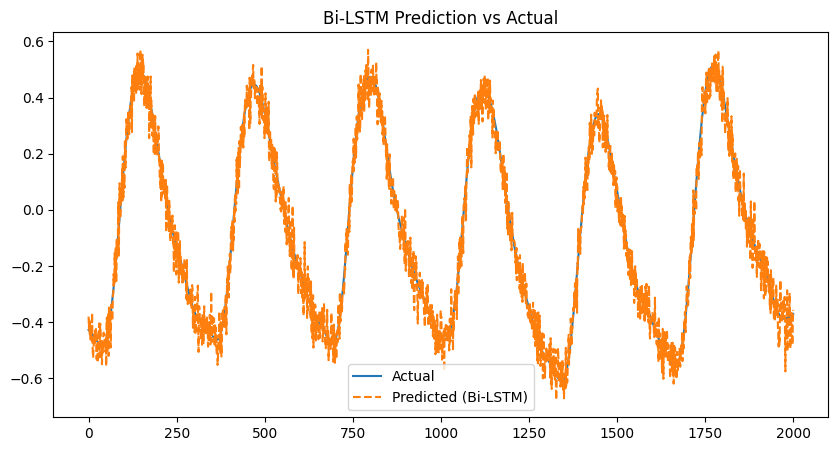

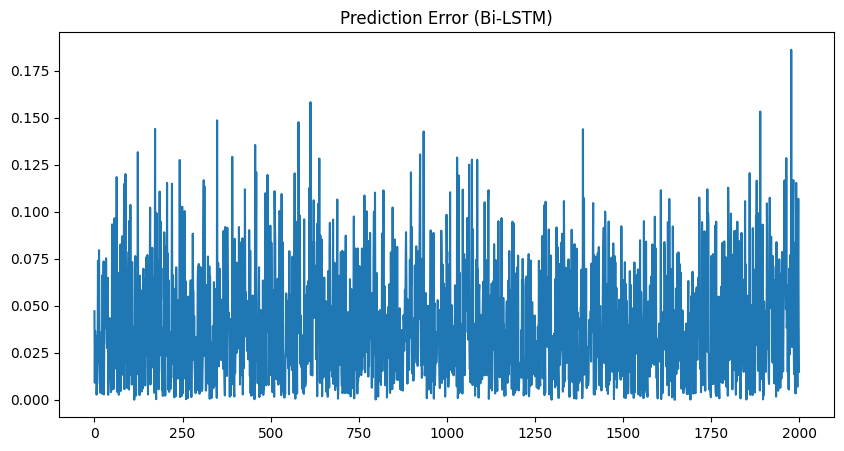

Bi-LSTM MSE: 0.002358645614234274
Bi-LSTM MAE: 0.03859084867567189


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import cheby2, filtfilt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional

# =========================
# 1. LOAD DATASET
# =========================
file_path = "samples2.csv"
df = pd.read_csv(file_path)

df.columns = df.columns.str.strip().str.replace("'", "").str.replace(" ", "")
df = df.apply(pd.to_numeric, errors='coerce').dropna()
df = df.iloc[:10000]

# =========================
# 2. EXTRACT SIGNAL
# =========================
pleth_signal = df["PLETH"].values

# =========================
# 3. ORIGINAL SIGNAL
# =========================
plt.figure(figsize=(10,5))
plt.plot(pleth_signal)
plt.title("Original Signal")
plt.show()

# =========================
# 4. ADD NOISE
# =========================
noise_std = 0.05
noisy_signal = pleth_signal + np.random.normal(0, noise_std, size=pleth_signal.shape)

plt.figure(figsize=(10,5))
plt.plot(noisy_signal)
plt.title("Noisy Signal")
plt.show()

# =========================
# 5. CHEBYSHEV FILTER
# =========================
def cheby_filter(data, cutoff=2, fs=100, order=4, rs=20):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = cheby2(order, rs, normal_cutoff, btype='low')
    return filtfilt(b, a, data)

cheby_output = cheby_filter(noisy_signal)

plt.figure(figsize=(10,5))
plt.plot(cheby_output)
plt.title("Filtered Signal (Chebyshev)")
plt.show()

# =========================
# 6. PREPARE DATA
# =========================
X = noisy_signal.reshape(-1, 1, 1)
y = cheby_output.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# =========================
# 7. BUILD BI-LSTM MODEL
# =========================
model = Sequential([
    Bidirectional(LSTM(50, return_sequences=True), input_shape=(1,1)),
    Dropout(0.2),
    Bidirectional(LSTM(50)),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# =========================
# 8. TRAIN MODEL
# =========================
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)

# =========================
# 9. LOSS GRAPH
# =========================
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.legend()
plt.title("Training Loss Curve (Bi-LSTM)")
plt.show()

# =========================
# 10. PREDICTION
# =========================
y_pred = model.predict(X_test)

# =========================
# 11. PREDICTION GRAPH
# =========================
plt.figure(figsize=(10,5))
plt.plot(y_test, label="Actual")
plt.plot(y_pred, label="Predicted (Bi-LSTM)", linestyle='dashed')
plt.legend()
plt.title("Bi-LSTM Prediction vs Actual")
plt.show()

# =========================
# 12. ERROR GRAPH
# =========================
error = np.abs(y_test - y_pred)

plt.figure(figsize=(10,5))
plt.plot(error)
plt.title("Prediction Error (Bi-LSTM)")
plt.show()

# =========================
# 13. METRICS
# =========================
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Bi-LSTM MSE: {mse}")
print(f"Bi-LSTM MAE: {mae}")